In [1]:
import pandas as pd

df = pd.read_csv("core_papp_dataset_16000.csv")

In [2]:
df.shape

(16880, 10)

In [3]:
df.isnull().sum()

assay_chembl_id       0
canonical_smiles      0
molecule_chembl_id    0
standard_type         0
standard_units        0
standard_value        0
type                  0
units                 0
value                 0
unit_normalized       0
dtype: int64

In [4]:
df.duplicated(subset='canonical_smiles').sum()

4465

In [5]:
df['standard_value'].describe()

count    16880.000000
mean        42.854516
std        177.673233
min         -4.500000
25%          1.767500
50%          8.400000
75%         22.000000
max       2704.000000
Name: standard_value, dtype: float64

In [6]:
df_avg = df.groupby('canonical_smiles', as_index=False).agg({
    'standard_value': 'mean'
})

In [7]:
df_avg.shape

(12415, 2)

In [8]:
df_avg['standard_value'].describe()

count    12415.000000
mean        49.484688
std        196.120587
min         -4.500000
25%          2.000000
50%          8.900000
75%         23.000000
max       2323.000000
Name: standard_value, dtype: float64

<Axes: >

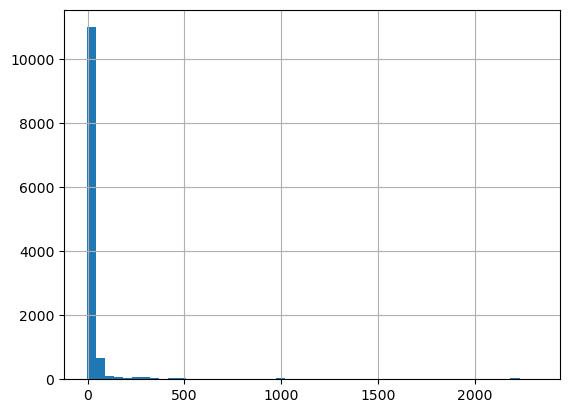

In [9]:
df_avg['standard_value'].hist(bins=50)

In [10]:
(df_avg['standard_value'] < 0).sum()

6

In [11]:
df_avg = df_avg[df_avg['standard_value'] > 0]

In [12]:
import numpy as np

df_avg['log_papp'] = np.log10(df_avg['standard_value'])

<Axes: >

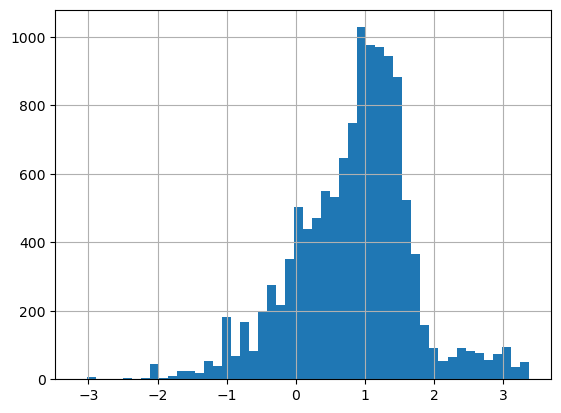

In [13]:
df_avg['log_papp'].hist(bins=50)

In [14]:
df_avg.to_csv(
    r"C:\Users\kiran\Cheminformatics_course\New_Project\Absorption\Data_set\final_12k_log_transformed_papp_dataset.csv",
    index=False
)